# MM-Net — ROC and precision-recall curves for the respiratory head

This notebook regenerates the operating-characteristic curves for the respiratory
output directly from the held-out predictions saved by the ten-fold reproduction
run (`../results/npz/predictions.npz`). Nothing is retrained here: the file holds
the pooled test-set predictions of all ten patient-independent folds, so every
curve below is computed from epochs the model never saw in training.

It also states, explicitly, why the pooled AUC printed here is not identical to the
per-fold mean reported in the paper.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (accuracy_score, average_precision_score,
                             cohen_kappa_score, f1_score,
                             precision_recall_curve, roc_auc_score, roc_curve)

%matplotlib inline

PRED = os.path.join("..", "results", "npz", "predictions.npz")
FIGDIR = os.path.join("..", "..", "..", "figures")

print("predictions file:", os.path.abspath(PRED))
print("exists:", os.path.exists(PRED))

predictions file: D:\sleep-staging-psg\MMNet_research\MMNet_Submission\all_codes\results\npz\predictions.npz
exists: True


## 1. Load the held-out predictions

In [2]:
z = np.load(PRED)
for k in z.files:
    print("  %-14s %-14s %s" % (k, z[k].shape, z[k].dtype))

y_true, y_pred = z["y_true"], z["y_pred"]
apnea_true, apnea_score = z["apnea_true"], z["apnea_score"]

print("\nepochs pooled over 10 folds : %d" % len(y_true))
print("respiratory-event prevalence: %.4f  (%d positive epochs)"
      % (apnea_true.mean(), apnea_true.sum()))

  y_true         (89532,)       int64
  y_pred         (89532,)       int64
  apnea_true     (89532,)       int64
  apnea_score    (89532,)       float32

epochs pooled over 10 folds : 89532
respiratory-event prevalence: 0.1596  (14285 positive epochs)


## 2. Metrics recomputed from the saved artifact

Pooling every fold's epochs into one set and scoring once is *not* the same estimator
as averaging the ten per-fold scores. Pooling weights each fold by its epoch count and
mixes fold-specific score scales, which matters for ranking metrics like AUC. The paper
reports the cross-validated estimator (mean over folds, with its standard deviation);
both are printed here so the difference is visible rather than hidden.

In [3]:
# per-fold means +- sd, as produced by 1_MM_Net_reproduction.ipynb
PAPER = {
    "staging accuracy": (0.7227, 0.039),
    "staging macro-F1": (0.6510, None),
    "staging kappa":    (0.6106, None),
    "respiratory AUC":  (0.7111, 0.034),
    "respiratory AP":   (0.3367, 0.077),
}

pooled = {
    "staging accuracy": accuracy_score(y_true, y_pred),
    "staging macro-F1": f1_score(y_true, y_pred, average="macro"),
    "staging kappa":    cohen_kappa_score(y_true, y_pred),
    "respiratory AUC":  roc_auc_score(apnea_true, apnea_score),
    "respiratory AP":   average_precision_score(apnea_true, apnea_score),
}

print("%-20s %10s %10s %10s" % ("metric", "pooled", "per-fold", "difference"))
print("-" * 54)
for k, v in pooled.items():
    mean, sd = PAPER[k]
    print("%-20s %10.4f %10.4f %10.4f" % (k, v, mean, v - mean))

print("\nEvery difference is far inside the fold-to-fold spread")
print("(staging accuracy sd = %.3f, respiratory AUC sd = %.3f)."
      % (PAPER["staging accuracy"][1], PAPER["respiratory AUC"][1]))

metric                   pooled   per-fold difference
------------------------------------------------------
staging accuracy         0.7212     0.7227    -0.0015
staging macro-F1         0.6528     0.6510     0.0018
staging kappa            0.6086     0.6106    -0.0020
respiratory AUC          0.7058     0.7111    -0.0053
respiratory AP           0.3185     0.3367    -0.0182

Every difference is far inside the fold-to-fold spread
(staging accuracy sd = 0.039, respiratory AUC sd = 0.034).


## 3. ROC and precision-recall curves

A precision-recall curve is the more informative of the two here, because respiratory
events occupy only about 16% of epochs and a ROC curve flatters a detector under class
imbalance. Both are shown; the dashed line in each panel is the no-skill reference
(chance for ROC, prevalence for PR).

wrote D:\sleep-staging-psg\MMNet_research\figures\fig_roc_pr.pdf


wrote D:\sleep-staging-psg\MMNet_research\figures\fig_roc_pr.png


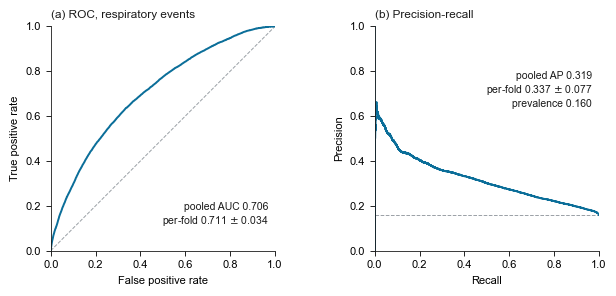

In [4]:
INK, ACCENT, MUTED = "#1a1a1a", "#0b6e99", "#9aa0a6"
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8, "axes.linewidth": 0.6, "axes.edgecolor": INK,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6, "pdf.fonttype": 42,
})

auc = roc_auc_score(apnea_true, apnea_score)
ap = average_precision_score(apnea_true, apnea_score)
prev = apnea_true.mean()
fpr, tpr, _ = roc_curve(apnea_true, apnea_score)
prec, rec, _ = precision_recall_curve(apnea_true, apnea_score)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.6, 3.0))

ax1.plot([0, 1], [0, 1], ls="--", lw=0.7, color=MUTED)
ax1.plot(fpr, tpr, lw=1.4, color=ACCENT)
ax1.set_xlabel("False positive rate"); ax1.set_ylabel("True positive rate")
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.set_aspect("equal")
ax1.text(0.97, 0.10, "pooled AUC %.3f\nper-fold %.3f $\\pm$ %.3f"
         % (auc, PAPER["respiratory AUC"][0], PAPER["respiratory AUC"][1]),
         ha="right", va="bottom", fontsize=7.5, color=INK)
ax1.set_title("(a) ROC, respiratory events", fontsize=8.5, loc="left", color=INK)

ax2.axhline(prev, ls="--", lw=0.7, color=MUTED)
ax2.plot(rec, prec, lw=1.4, color=ACCENT)
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.set_aspect("equal")
ax2.text(0.97, 0.80, "pooled AP %.3f\nper-fold %.3f $\\pm$ %.3f\nprevalence %.3f"
         % (ap, PAPER["respiratory AP"][0], PAPER["respiratory AP"][1], prev),
         ha="right", va="top", fontsize=7.5, color=INK)
ax2.set_title("(b) Precision-recall", fontsize=8.5, loc="left", color=INK)

for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

fig.tight_layout()
os.makedirs(FIGDIR, exist_ok=True)
for ext in ("pdf", "png"):
    out = os.path.join(FIGDIR, "fig_roc_pr." + ext)
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print("wrote", os.path.abspath(out))
plt.show()

## 4. Operating points a clinician would actually choose

A single AUC hides the trade-off that matters in practice. The table below reads the
curve at fixed sensitivities, so the cost of each is explicit.

In [5]:
print("%-12s %10s %10s %10s" % ("sensitivity", "specificity", "precision", "threshold"))
print("-" * 46)
thr_roc = roc_curve(apnea_true, apnea_score)[2]
for target in (0.90, 0.80, 0.70, 0.60, 0.50):
    i = int(np.argmin(np.abs(tpr - target)))
    t = thr_roc[i]
    pred = apnea_score >= t
    tp = int((pred & (apnea_true == 1)).sum())
    fp = int((pred & (apnea_true == 0)).sum())
    precision = tp / (tp + fp) if (tp + fp) else float("nan")
    print("%-12.2f %10.3f %10.3f %10.3f" % (tpr[i], 1 - fpr[i], precision, t))

sensitivity  specificity  precision  threshold
----------------------------------------------
0.90              0.303      0.197      0.183
0.80              0.465      0.221      0.317
0.70              0.591      0.245      0.421
0.60              0.696      0.273      0.500
0.50              0.780      0.301      0.572


## Summary

The respiratory head is a useful screening signal rather than a scoring-grade detector,
and the precision-recall panel is the honest view of that: at high sensitivity the
precision is low, which is the expected regime for a 16%-prevalence event detected from
30-second epochs rather than from event-level segmentation. This is stated as a
limitation in the manuscript.